# 05. VaR and CVaR Stress Testing

Compute one-day historical and normally distributed Monte Carlo VaR/CVaR for an equal-weight
portfolio of eight sector ETFs. Two fixed stress windows are compared with the full sample,
which includes those windows.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.risk_metrics import historical_var, historical_cvar, monte_carlo_var, monte_carlo_cvar, stress_test

## Portfolio daily returns

Equal-weight average of the 8 sector ETF daily returns.

In [2]:
prices = pd.read_csv('../data/raw/prices.csv', index_col=0, parse_dates=True)

sector_cols = [c for c in prices.columns if not c.startswith('^')]
sector_returns = prices[sector_cols].pct_change(fill_method=None).dropna(how='all')
portfolio_returns = sector_returns.mean(axis=1).dropna()

print(f"Sector ETFs: {sector_cols}")
print(f"Portfolio return series: {len(portfolio_returns)} days, {portfolio_returns.index.min().date()} to {portfolio_returns.index.max().date()}")

Sector ETFs: ['XLF', 'XLK', 'XLE', 'XLU', 'XLY', 'XLP', 'XLV', 'XLI']
Portfolio return series: 2139 days, 2018-01-03 to 2026-07-10


## VaR / CVaR at 95% and 99%, historical vs Monte Carlo

In [3]:
rows = []
for confidence in [0.95, 0.99]:
    rows.append({
        'confidence': confidence,
        'method': 'historical',
        'VaR': historical_var(portfolio_returns, confidence),
        'CVaR': historical_cvar(portfolio_returns, confidence),
    })
    rows.append({
        'confidence': confidence,
        'method': 'monte_carlo',
        'VaR': monte_carlo_var(portfolio_returns, confidence),
        'CVaR': monte_carlo_cvar(portfolio_returns, confidence),
    })

risk_table = pd.DataFrame(rows)
risk_table

,confidence,method,VaR,CVaR
0,0.95,historical,0.015668,0.027175
1,0.95,monte_carlo,0.018412,0.023150
2,0.99,historical,0.030835,0.049645
3,0.99,monte_carlo,0.026339,0.030316


**Reading the table**: the historical method uses the empirical return distribution, while the
Monte Carlo estimate samples from a fitted normal distribution. Differences are consistent with
skew, heavy tails and simulation error; they are not by themselves a formal normality test.

## Stress windows vs full sample

Compare historical VaR/CVaR in the full sample with the March 2020 COVID selloff and the 2022
rate-hike calendar year. The full sample is a reference period, not a clean normal-period subset.

In [4]:
full_sample = {
    'var_95': historical_var(portfolio_returns, 0.95),
    'cvar_95': historical_cvar(portfolio_returns, 0.95),
    'n_observations': len(portfolio_returns),
}

covid_crash = stress_test(portfolio_returns, '2020-02-15', '2020-04-15')
rate_hike_2022 = stress_test(portfolio_returns, '2022-01-01', '2022-12-31')

stress_comparison = pd.DataFrame([
    {'period': 'full_sample', **full_sample},
    {'period': 'covid_crash_2020', **covid_crash},
    {'period': 'rate_hike_2022', **rate_hike_2022},
])
stress_comparison

,period,var_95,cvar_95,n_observations
0,full_sample,0.015668,0.027175,2139
1,covid_crash_2020,0.086208,0.101071,41
2,rate_hike_2022,0.021868,0.029133,251


In [5]:
covid_multiple = stress_comparison.loc[1, 'var_95'] / stress_comparison.loc[0, 'var_95']
hike_multiple = stress_comparison.loc[2, 'var_95'] / stress_comparison.loc[0, 'var_95']

print(f"COVID crash VaR is {covid_multiple:.1f}x the full-sample VaR")
print(f"2022 rate hike VaR is {hike_multiple:.1f}x the full-sample VaR")

COVID crash VaR is 5.5x the full-sample VaR
2022 rate hike VaR is 1.4x the full-sample VaR


## Returns time series with stress windows marked

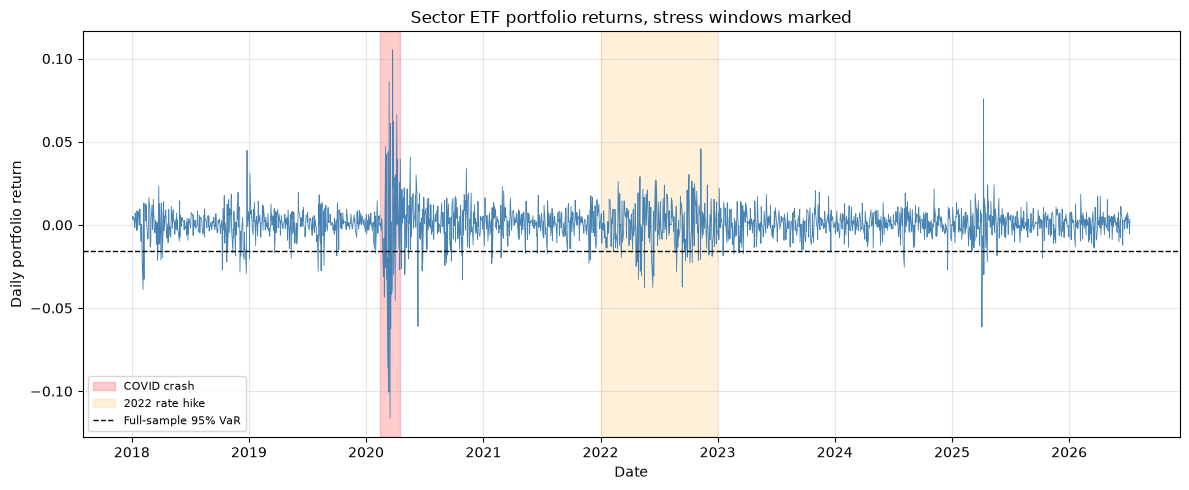

Saved figure: figures/05_returns_stress_windows.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(portfolio_returns.index, portfolio_returns.values, color='steelblue', linewidth=0.6)

ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-15'), alpha=0.2, color='red', label='COVID crash')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), alpha=0.15, color='orange', label='2022 rate hike')

ax.axhline(-full_sample['var_95'], color='black', linestyle='--', linewidth=1, label='Full-sample 95% VaR')

ax.set_xlabel('Date')
ax.set_ylabel('Daily portfolio return')
ax.set_title('Sector ETF portfolio returns, stress windows marked')
ax.legend(loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('../figures/05_returns_stress_windows.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/05_returns_stress_windows.png")